In [1]:
""" ETL ON OPENWEATHER """ 

' ETL ON OPENWEATHER '

In [2]:
""" EXTRACTION MODE """ 

' EXTRACTION MODE '

In [3]:
# import libaries
import pandas as pd
import requests as rt
import openpyxl as xl
from datetime import datetime
import pycountry as pct
import sqlite3
import matplotlib.pyplot as plt

In [4]:
# Extraction

# read where the file is stored
with open(r"C:/Users/HomePC/Downloads/DA/AnalystLab Africa Community/Week 7/test.txt", "r") as file:
    API_KEY = file.read().strip()
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

# 21 major nigerian cities
city_list = [
    "Asaba","Lagos","Abuja","Port Harcourt","Kano", "Ibadan","Benin City", "Enugu", "Aba","Onitsha","Warri", "Kaduna", "Jos", "Maiduguri", "Uyo", "Calabar", "Owerri","Akure", "Ilorin", "Abeokuta", "Sokoto"
]
#city_list = ["Lagos", "Abuja", "Port Harcourt"]
weather_data =[] # List to store wheather data for dataframe usage



for city in city_list:
    # Looping through the cities
    
    param={
        # Parameters to send to the api
        "q":city,
        "appid":API_KEY,
        "unit":"metric" # Get temperature value in Celcius instead of kelvin
    }
    
    # Make the request
    get_data = rt.get(BASE_URL, params=param)
    response = get_data # personal

    # Check if the response was successfull
    if response.status_code == 200:
        data = response.json()  # convert response to json
        
        
        # Extract the required fields
        weather_data.append( # Append into the empty weather_data list
            { 
                # for dataframe(table), the keys are the series(column) and values are the data
                "Country":  data["sys"]["country"],
                "City": data["name"],
                "Temperature (°C)": data["main"]["temp"],
                "Humidity (%)": data["main"]["humidity"],
                "Wind Speed (m/s)": data["wind"]["speed"],
                #"Weather Icon": data["weather"][0]["icon"], # [0] start from the first whether condition
                "Weather Condition": data["weather"][0]["main"], # [0] start from the first whether conditio
                "Weather description": data["weather"][0]["description"], # [0] start from the first whether condition
                "Date Time": datetime.fromtimestamp(data["dt"]) #.strftime("%Y-%m-%d %I:%M:%S %p"), # convert date_time string to readable date_time
             

                

            }
            )
        
    else:
        print(f"Could not retrieve data for {city}")
        
        # troubleshooting code
    # print(response.status_code)
    # print(response.text)

# print data)
print(weather_data)

[{'Country': 'NG', 'City': 'Asaba', 'Temperature (°C)': 303.74, 'Humidity (%)': 68, 'Wind Speed (m/s)': 1.18, 'Weather Condition': 'Clouds', 'Weather description': 'overcast clouds', 'Date Time': datetime.datetime(2026, 6, 18, 16, 5, 45)}, {'Country': 'NG', 'City': 'Lagos', 'Temperature (°C)': 303.13, 'Humidity (%)': 64, 'Wind Speed (m/s)': 3.14, 'Weather Condition': 'Clouds', 'Weather description': 'overcast clouds', 'Date Time': datetime.datetime(2026, 6, 18, 16, 8, 37)}, {'Country': 'NG', 'City': 'Abuja', 'Temperature (°C)': 302.51, 'Humidity (%)': 63, 'Wind Speed (m/s)': 2.38, 'Weather Condition': 'Clouds', 'Weather description': 'overcast clouds', 'Date Time': datetime.datetime(2026, 6, 18, 16, 9, 15)}, {'Country': 'NG', 'City': 'Port Harcourt', 'Temperature (°C)': 302.89, 'Humidity (%)': 66, 'Wind Speed (m/s)': 3.28, 'Weather Condition': 'Clouds', 'Weather description': 'overcast clouds', 'Date Time': datetime.datetime(2026, 6, 18, 16, 7, 59)}, {'Country': 'NG', 'City': 'Kano', '

In [5]:
""" TRANSFORMATION MODE """ 

' TRANSFORMATION MODE '

In [6]:
# Send data into datafarme
raw_data = pd.DataFrame(weather_data)
print(raw_data.to_string())

   Country           City  Temperature (°C)  Humidity (%)  Wind Speed (m/s) Weather Condition Weather description           Date Time
0       NG          Asaba            303.74            68              1.18            Clouds     overcast clouds 2026-06-18 16:05:45
1       NG          Lagos            303.13            64              3.14            Clouds     overcast clouds 2026-06-18 16:08:37
2       NG          Abuja            302.51            63              2.38            Clouds     overcast clouds 2026-06-18 16:09:15
3       NG  Port Harcourt            302.89            66              3.28            Clouds     overcast clouds 2026-06-18 16:07:59
4       NG           Kano            312.02            19              1.69             Clear           clear sky 2026-06-18 16:09:18
5       NG         Ibadan            302.92            64              1.03            Clouds     overcast clouds 2026-06-18 16:09:20
6       NG     Benin City            301.68            81     

In [7]:
# CHECK D-TYPE
print(raw_data.dtypes)

Country                        object
City                           object
Temperature (°C)              float64
Humidity (%)                    int64
Wind Speed (m/s)              float64
Weather Condition              object
Weather description            object
Date Time              datetime64[ns]
dtype: object


In [8]:
# Check matric shape
print(raw_data.shape)


(21, 8)


In [9]:
# CHECK NULL NALUE
print(raw_data.isnull().sum())


Country                0
City                   0
Temperature (°C)       0
Humidity (%)           0
Wind Speed (m/s)       0
Weather Condition      0
Weather description    0
Date Time              0
dtype: int64


In [10]:
# Duplicates and drop
print(raw_data.duplicated())

# if Duplicates found please drop
raw_data.drop_duplicates(inplace=True)
print(raw_data.dtypes)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
dtype: bool
Country                        object
City                           object
Temperature (°C)              float64
Humidity (%)                    int64
Wind Speed (m/s)              float64
Weather Condition              object
Weather description            object
Date Time              datetime64[ns]
dtype: object


In [11]:
# Properly format date_time and remane

#  Because data transformation was giving me issues, i had to force it into extraction

# change datatype
raw_data["Date Time"] = pd.to_datetime(raw_data["Date Time"])

# confirm
print(raw_data.dtypes)


Country                        object
City                           object
Temperature (°C)              float64
Humidity (%)                    int64
Wind Speed (m/s)              float64
Weather Condition              object
Weather description            object
Date Time              datetime64[ns]
dtype: object


In [12]:
#re-enforce dataypes again because my date seems to be misbehaving
raw_data["Temperature (°C)"] = raw_data["Temperature (°C)"].astype(float).round(1)
raw_data["Humidity (%)"] = raw_data["Humidity (%)"].astype(int)
raw_data["Wind Speed (m/s)"] = raw_data["Wind Speed (m/s)"].astype(float).round(1)

print(raw_data.to_string())

   Country           City  Temperature (°C)  Humidity (%)  Wind Speed (m/s) Weather Condition Weather description           Date Time
0       NG          Asaba             303.7            68               1.2            Clouds     overcast clouds 2026-06-18 16:05:45
1       NG          Lagos             303.1            64               3.1            Clouds     overcast clouds 2026-06-18 16:08:37
2       NG          Abuja             302.5            63               2.4            Clouds     overcast clouds 2026-06-18 16:09:15
3       NG  Port Harcourt             302.9            66               3.3            Clouds     overcast clouds 2026-06-18 16:07:59
4       NG           Kano             312.0            19               1.7             Clear           clear sky 2026-06-18 16:09:18
5       NG         Ibadan             302.9            64               1.0            Clouds     overcast clouds 2026-06-18 16:09:20
6       NG     Benin City             301.7            81     

In [13]:
# I want to be seeing full country name


def get_country_name(code):
    country = pct.countries.get(alpha_2=code)
    return country.name if country else code

# Apply the transformation
raw_data["Country"] = raw_data["Country"].apply(get_country_name)



In [14]:
# Add discriptive column to the weather conditionr


# Weather description from the API
weather_description = data["weather"][0]["description"].lower()

# Dictionary containing explanations for weather conditions
weather_meaning = {
    # Clear
    "clear sky": "The sky is completely clear with no visible clouds.",

    # Clouds
    "few clouds": "About 11–25% of the sky is covered with clouds.",
    "scattered clouds": "About 25–50% of the sky is covered with clouds.",
    "broken clouds": "About 51–84% of the sky is covered with clouds, but it is not completely overcast.",
    "overcast clouds": "About 85–100% of the sky is covered with clouds.",

    # Drizzle
    "light intensity drizzle": "Very light rain consisting of small droplets.",
    "drizzle": "Light rain falling steadily.",
    "heavy intensity drizzle": "A heavier drizzle than normal.",
    "shower drizzle": "Intermittent light drizzle showers.",

    # Rain
    "light rain": "A gentle rainfall with low intensity.",
    "moderate rain": "Steady rainfall with moderate intensity.",
    "heavy intensity rain": "Heavy rainfall that may reduce visibility.",
    "very heavy rain": "Extremely heavy rainfall with possible flooding.",
    "extreme rain": "Dangerously heavy rainfall that may cause severe flooding.",
    "freezing rain": "Rain that freezes on contact, creating slippery surfaces.",
    "shower rain": "Rain occurring in short bursts or showers.",

    # Thunderstorm
    "thunderstorm": "A storm accompanied by thunder and lightning.",
    "thunderstorm with light rain": "Thunderstorm with light rainfall.",
    "thunderstorm with heavy rain": "Thunderstorm accompanied by heavy rainfall.",
    "ragged thunderstorm": "An irregular or scattered thunderstorm.",

    # Snow
    "light snow": "Light snowfall.",
    "snow": "Steady snowfall.",
    "heavy snow": "Heavy snowfall reducing visibility.",
    "sleet": "A mixture of rain and snow.",
    "rain and snow": "Rain mixed with snow.",
    "shower snow": "Snow falling in short showers.",

    # Atmosphere
    "mist": "Fine water droplets reducing visibility slightly.",
    "smoke": "Smoke particles present in the atmosphere.",
    "haze": "Dust or moisture causing reduced visibility.",
    "fog": "Dense water droplets greatly reducing visibility.",
    "sand": "Sand particles suspended in the air.",
    "dust": "Dust particles suspended in the atmosphere.",
    "ash": "Volcanic ash present in the atmosphere.",
    "squall": "A sudden, strong increase in wind speed.",
    "tornado": "A violently rotating column of air extending from a thunderstorm to the ground."
}

# Get the explanation
"""
raw_data["Weather Meaning"] = weather_meaning.get(
    weather_description,
    "No detailed description available."
)"""


raw_data["Weather Meaning"] = (
    raw_data["Weather description"]
    .str.lower()
    .map(weather_meaning)
    .fillna("No detailed description available.")
)


In [15]:
#confirm
print(raw_data.to_string())
print(f"\n\n\n{raw_data.dtypes}")

# Transformation done
transformed_data = raw_data

    Country           City  Temperature (°C)  Humidity (%)  Wind Speed (m/s) Weather Condition Weather description           Date Time                                                                     Weather Meaning
0   Nigeria          Asaba             303.7            68               1.2            Clouds     overcast clouds 2026-06-18 16:05:45                                    About 85–100% of the sky is covered with clouds.
1   Nigeria          Lagos             303.1            64               3.1            Clouds     overcast clouds 2026-06-18 16:08:37                                    About 85–100% of the sky is covered with clouds.
2   Nigeria          Abuja             302.5            63               2.4            Clouds     overcast clouds 2026-06-18 16:09:15                                    About 85–100% of the sky is covered with clouds.
3   Nigeria  Port Harcourt             302.9            66               3.3            Clouds     overcast clouds 2026-06-1

In [16]:
""" LOADING MODE """ 

' LOADING MODE '

In [17]:
# CSV
transformed_data.to_csv("../data/weather_data.csv", index=False)


In [18]:
# Excel
transformed_data.to_excel("../data/weather_data.xlsx", index=False)


In [19]:
# SQLite
# Create/connect to database
conn = sqlite3.connect("../data/weather_data.db")

# Save dataframe to SQL table
transformed_data.to_sql("weather", conn, if_exists="replace", index=False)

# Close connection
conn.close()

In [20]:
""" ANALYSIS """ 

' ANALYSIS '

In [21]:
# Analyse from the CSV file
df = pd.read_csv("../data/weather_data.csv")

In [22]:
# statistics
print(df.describe())

       Temperature (°C)  Humidity (%)  Wind Speed (m/s)
count         21.000000     21.000000         21.000000
mean         304.400000     58.190476          2.276190
std            3.544996     17.884684          1.164004
min          301.700000     19.000000          0.900000
25%          302.500000     56.000000          1.300000
50%          303.100000     64.000000          2.400000
75%          304.300000     68.000000          2.900000
max          313.500000     81.000000          5.700000


In [23]:
# Check file
print(f"The shape of this file is {df.shape} rows and cols")

The shape of this file is (21, 9) rows and cols


In [24]:
# Date frame details
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              21 non-null     object 
 1   City                 21 non-null     object 
 2   Temperature (°C)     21 non-null     float64
 3   Humidity (%)         21 non-null     int64  
 4   Wind Speed (m/s)     21 non-null     float64
 5   Weather Condition    21 non-null     object 
 6   Weather description  21 non-null     object 
 7   Date Time            21 non-null     object 
 8   Weather Meaning      21 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.6+ KB
None


In [25]:
#Change date to date
df["Date Time"] = pd.to_datetime(df["Date Time"])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Country              21 non-null     object        
 1   City                 21 non-null     object        
 2   Temperature (°C)     21 non-null     float64       
 3   Humidity (%)         21 non-null     int64         
 4   Wind Speed (m/s)     21 non-null     float64       
 5   Weather Condition    21 non-null     object        
 6   Weather description  21 non-null     object        
 7   Date Time            21 non-null     datetime64[ns]
 8   Weather Meaning      21 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 1.6+ KB
None


In [26]:
print(df.to_string())

    Country           City  Temperature (°C)  Humidity (%)  Wind Speed (m/s) Weather Condition Weather description           Date Time                                                                     Weather Meaning
0   Nigeria          Asaba             303.7            68               1.2            Clouds     overcast clouds 2026-06-18 16:05:45                                    About 85–100% of the sky is covered with clouds.
1   Nigeria          Lagos             303.1            64               3.1            Clouds     overcast clouds 2026-06-18 16:08:37                                    About 85–100% of the sky is covered with clouds.
2   Nigeria          Abuja             302.5            63               2.4            Clouds     overcast clouds 2026-06-18 16:09:15                                    About 85–100% of the sky is covered with clouds.
3   Nigeria  Port Harcourt             302.9            66               3.3            Clouds     overcast clouds 2026-06-1

In [27]:
# Analysis
highest_temp = df.loc[df["Temperature (°C)"].idxmax()]
highest_wind_speed = df.loc[df["Wind Speed (m/s)"].idxmax()]
highest_humdity = df.loc[df["Humidity (%)"].idxmax()]
                        
lowest_temp = df.loc[df["Temperature (°C)"].idxmin()]
lowest_wind_speed = df.loc[df["Wind Speed (m/s)"].idxmin()]
lowest_humdity = df.loc[df["Humidity (%)"].idxmin()]

avg_temp = df["Temperature (°C)"].mean().round(1)
avg_wind_speed = df["Wind Speed (m/s)"].mean().round(1)
avg_humdity = df["Humidity (%)"].mean().round(1)

top_weather_condition = df['Weather Condition'].value_counts().idxmax()
bottom_weather_condition = df['Weather Condition'].value_counts().idxmin()

In [28]:
print("WEATHER ANALYSIS REPORT")
print("----------------------------")
print(f"Hottest City: {highest_temp['City']}")
print(f"Coldest City: {lowest_temp['City']}")
print(f"Most Humid City: {highest_humdity['City']}")
#print(f"Average Temperature: {avg_temp["Temperature (°C)"][:.2f}°C")

WEATHER ANALYSIS REPORT
----------------------------
Hottest City: Maiduguri
Coldest City: Benin City
Most Humid City: Benin City


In [29]:

# Dictionary containing explanations for weather conditions
weather = {"Atmosphere": "Atomspheric", "Clear": "Clear", "Clouds":"Cloudy", "Snow": "Snow", "Drizzle": "Drizzling", "Rain":"Rainy", "Thunderstorm": "Thunderstorm" }
#condition_experience = (df["Weather Condition"].str.lower().map(weather).fillna('Unknown Weather'))

condition_experience = weather.get(top_weather_condition, 'Unknown Weather')

print("FINDINGS")
print(f"\033[1m{highest_temp['City']}\033[0m recorded the highest temperature.")
print(f"\033[1m{lowest_temp['City']}\033[0m recorded the lowest temperature.")
print(f"\033[1m{highest_humdity['City']}\033[0m had the highest humdidity.")

print(f"Most cities experienced \033[1m{condition_experience}\033[0m condition.")

print(f"Average Temperature: \033[1m{avg_temp}°C\033[0m")



FINDINGS
Maiduguri recorded the highest temperature.
Benin City recorded the lowest temperature.
Benin City had the highest humdidity.
Most cities experienced Cloudy condition.
Average Temperature: 304.4°C


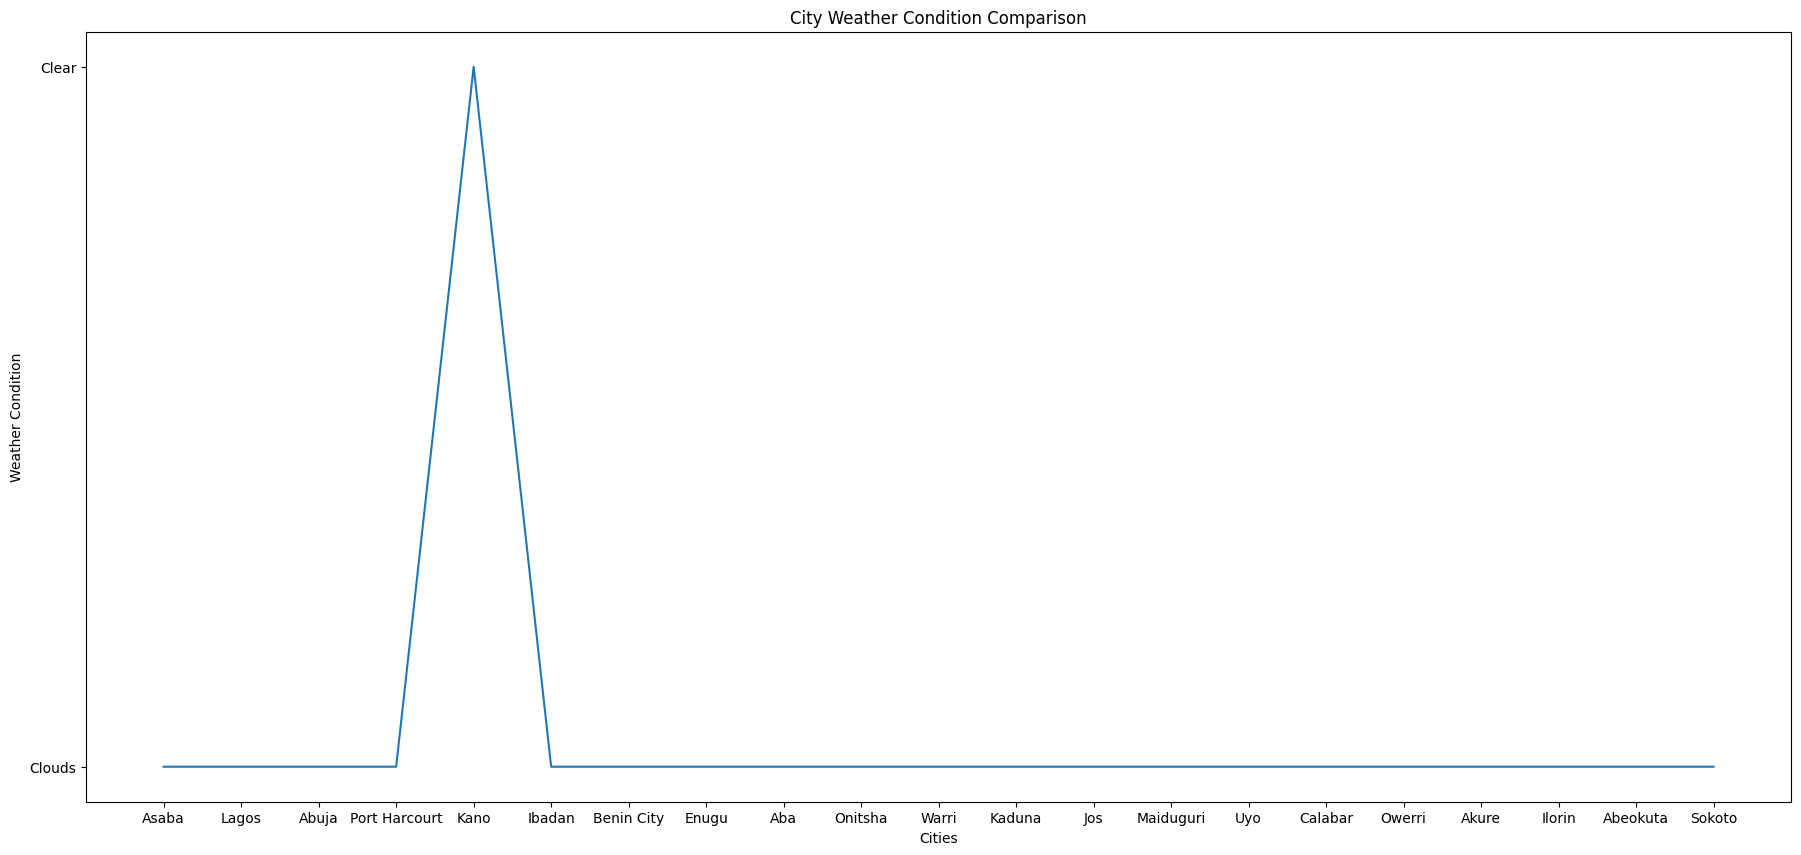

In [30]:
plt.figure(figsize=(22,10))
plt.plot(df["City"], df["Weather Condition"])
plt.title("City Weather Condition Comparison")
plt.ylabel("Weather Condition")
plt.xlabel("Cities")
plt.show()

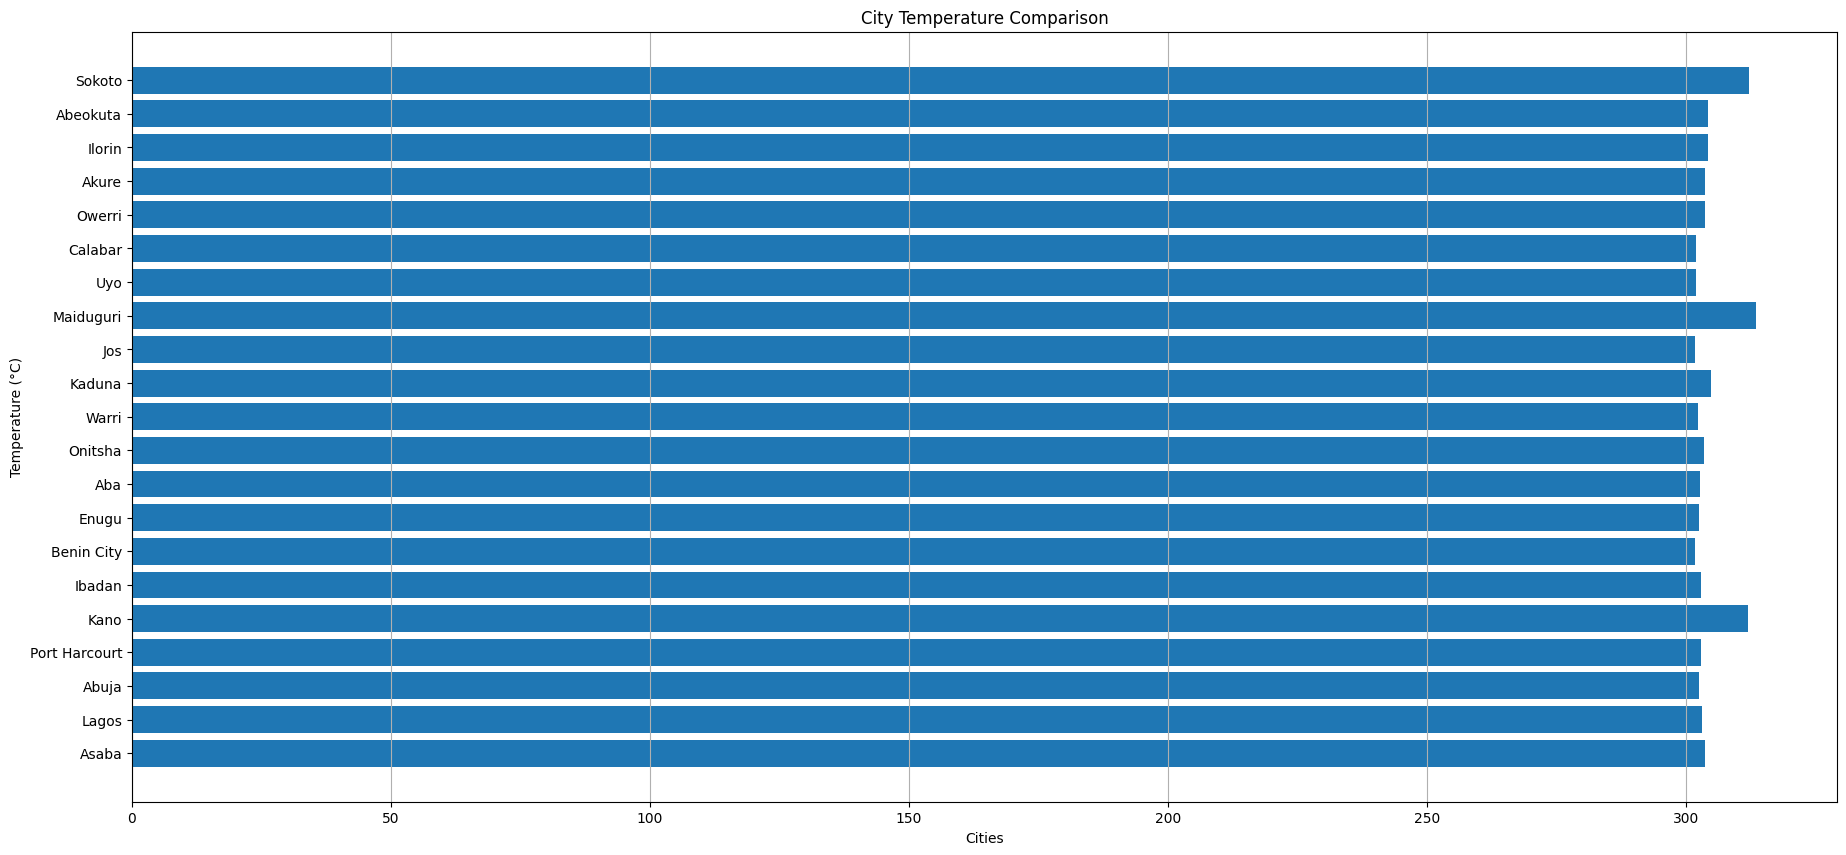

In [31]:
plt.figure(figsize=(22,10))
plt.barh(df["City"], df["Temperature (°C)"])
plt.title("City Temperature Comparison")
plt.ylabel("Temperature (°C)")
plt.xlabel("Cities")
plt.grid(axis='x')
plt.show()